In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# add code directory to path
import sys
import os
sys.path.append(os.path.join(os.path.abspath(''), 'code'))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [85]:
from config import load_config
from bootstrap import get_oh_table

In [5]:
config = load_config("configs/config_original_paper.yaml", args=["--opmode", "mean"])
sequences_df = pd.read_csv(config["dataset_path"])
wt_seq = sequences_df.loc[0]
mean_embeddings_with_wt = np.load(config["embeddings_path"])

config = load_config("configs/config_original_paper.yaml", args=["--opmode", "flat"])
flat_embeddings_with_wt = np.load(config["embeddings_path"])

['--opmode', 'mean']
Loaded configuration:
  root_path: /home/labs/fleishman/omripo/Projects/adaptive_learning
  data_dir_name: data
  pretraining_dir_name: pretraining
  bootstrap_dir_name: bootstrap
  results_dir_name: results
  enzyme: PTE
  substrate: malathion
  dataset_filename: tested_variants.csv
  tag: original_paper
  weights_filename: final_model.pt
  model_type: plm
  finetune: False
  opmode: mean
  train_type: msa_backbone
  cluster_method: spherical_kmeans
  nmuts_column: num_muts
  continuous_activity_column: fold_improvement
  sequence_column_name: full_seq
  activity_column_name: inactive
  first_column_name: I106
  last_column_name: M317
  plm_name: esm2_t12_35M_UR50D
  ref_seq: DRINTVRGPITISEAGFTLTHEHICGSSAGFLRAWPEFFGSRKALAEKAVRGLRRARAAGVRTIVDVSTFDIGRDVSLLAEVSRAADVHIVAATGLWFDPPLSMRLRSVEELTQFFLREIQYGIEDTGIRAGIIKVATTGKATPFQELVLKAAARASLATGVPVTTHTAASQRDGEQQAAIFESEGLSPSRVCIGHSDDTDDLSYLTALAARGYLIGLDHIPHSAIGLEDNASASALLGIRSWQTRALLIKALIDQGYMKQILVSNDWLFGFSSYVTNIMDVMDRVNPDGMAF

In [90]:
oh_df_with_wt, activity, design_numbers = get_oh_table(config["dataset_path"], first_col=config["first_column_name"], 
                                               last_col=config["last_column_name"], 
                                               y_col=config["activity_column_name"])

In [91]:
mean_embeddings_with_wt.shape, flat_embeddings_with_wt.shape, oh_df_with_wt.shape

((50, 480), (50, 3840), (50, 22))

In [92]:
oh_df = oh_df_with_wt.iloc[1:, :]

In [7]:
wt_mean_emb = mean_embeddings_with_wt[0]
wt_flat_emb = flat_embeddings_with_wt[0]

mean_delta_embeddings = mean_embeddings_with_wt - wt_mean_emb
flat_delta_embeddings = flat_embeddings_with_wt - wt_flat_emb
assert (mean_delta_embeddings[0] == np.zeros_like(wt_mean_emb)).all()
assert (flat_delta_embeddings[0] == np.zeros_like(wt_flat_emb)).all()

# drop the wt row
mean_embeddings = mean_embeddings_with_wt[1:]
flat_embeddings = flat_embeddings_with_wt[1:]
mean_delta_embeddings = mean_delta_embeddings[1:]
flat_delta_embeddings = flat_delta_embeddings[1:]

In [8]:
experimental_results = pd.read_csv(f"{config["data_dir_path"]}/experimental_results.csv")

In [56]:
substrate = "p-nitrophenyl_octanoate"
y = np.log(experimental_results[substrate] + 1e-8)
y.shape

(49,)

In [10]:
from sklearn.cross_decomposition import CCA

In [12]:
mean_embeddings.shape

(49, 480)

In [57]:
# CCA on each embedding type
cca_mean = CCA(n_components=1)
cca_mean.fit(mean_embeddings, y)
predictions_mean = cca_mean.predict(mean_embeddings)
cca_flat = CCA(n_components=1)
cca_flat.fit(flat_embeddings, y)
predictions_flat = cca_flat.predict(flat_embeddings)
cca_mean_delta = CCA(n_components=1)
cca_mean_delta.fit(mean_delta_embeddings, y)
predictions_mean_delta = cca_mean_delta.predict(mean_delta_embeddings)
cca_flat_delta = CCA(n_components=1)
cca_flat_delta.fit(flat_delta_embeddings, y)
predictions_flat_delta = cca_flat_delta.predict(flat_delta_embeddings)

In [58]:
predictions_mean, y

(array([ 0.83381931,  1.34913509,  0.32827936,  0.02075859,  0.30436364,
         1.42154254, -0.8592438 ,  1.61989539, -0.94416634, -8.01395942,
         0.31649062,  0.94032996, -0.32362432,  0.0486717 , -0.70067663,
        -1.1157558 , -1.05052055, -0.85924386, -0.70067661, -0.44900158,
        -8.01395938,  1.15409143,  0.16589013,  0.76846682,  1.79371329,
         0.51209186,  1.13724253,  1.355751  ,  0.3043637 ,  1.90119191,
         1.66627054,  0.32827932, -0.08217438,  1.0715485 ,  0.23500781,
         0.14129928,  0.48407665, -0.56590995, -0.78854832,  0.67300587,
        -8.01395937,  0.65189454, -0.42077837,  0.1658901 , -8.01395926,
        -0.42077824,  0.04867153,  1.2452742 , -0.21009742]),
 0      2.486572
 1      3.704261
 2      1.291984
 3      0.565314
 4      1.235471
 5      3.875359
 6     -1.514128
 7      4.344065
 8     -1.714798
 9    -18.420681
 10     1.264127
 11     2.738256
 12    -0.248461
 13     0.631272
 14    -1.139434
 15    -2.120263
 16    -1

In [65]:
corr_mean = np.corrcoef(predictions_mean, y)[0,1]
corr_flat = np.corrcoef(predictions_flat, y)[0,1]
corr_mean_delta = np.corrcoef(predictions_mean_delta, y)[0,1]
corr_flat_delta = np.corrcoef(predictions_flat_delta, y)[0,1]

In [66]:
corr_mean, corr_flat, corr_mean_delta, corr_flat_delta

(np.float64(0.9999999999999981),
 np.float64(0.9999999999999996),
 np.float64(0.9999999999999988),
 np.float64(0.9999999999999996))

In [64]:
np.corrcoef(predictions_mean, y)

array([[1., 1.],
       [1., 1.]])

In [ ]:
# scatter plots
fig = px.scatter(x=predictions_mean, y=y, labels={'x':'CCA Prediction (Mean Embedding)', 'y':'Experimental Log Activity'}, title='CCA Predictions vs Experimental Results (Mean Embedding)')
fig.show()

In [67]:
from sklearn.linear_model import LinearRegression

In [93]:
regreassion_mean = LinearRegression()
regreassion_mean.fit(mean_embeddings, y)
y_pred_mean = regreassion_mean.predict(mean_embeddings)
regression_flat = LinearRegression()
regression_flat.fit(flat_embeddings, y)
y_pred_flat = regression_flat.predict(flat_embeddings)
regression_mean_delta = LinearRegression()
regression_mean_delta.fit(mean_delta_embeddings, y)
y_pred_mean_delta = regression_mean_delta.predict(mean_delta_embeddings)
regression_flat_delta = LinearRegression()
regression_flat_delta.fit(flat_delta_embeddings, y)
y_pred_flat_delta = regression_flat_delta.predict(flat_delta_embeddings)
regression_oh = LinearRegression()
regression_oh.fit(oh_df, y)
y_pred_oh = regression_oh.predict(oh_df)

In [94]:
y_pred_oh, y.to_numpy()

(array([ 3.22717674,  4.65097454, -0.01476155, -1.05150786,  1.03144775,
         5.31563085, -3.3526335 ,  0.95836795, -4.38712581, -8.46418316,
         5.17123518,  1.5039353 , -2.75929306, -1.35705927, -1.37302635,
        -3.57105023, -6.92150954, -5.46220896, -2.76066547, -2.97770979,
        -4.01220209,  7.21727329,  2.38632902,  2.72527567,  3.83075789,
        -1.77286095,  5.47774695,  6.86401365,  1.17749833,  3.33458319,
         4.44006542, -0.76976303, -3.08573003, -2.49479729,  3.21766851,
         4.62231   , -1.12398656, -2.21889504, -1.6279623 , -1.64392938,
        -7.99011335,  2.56893785, -1.4772462 , -2.94083138, -5.65577157,
        -3.76552912, -0.56285781,  1.03320346, -3.71894985]),
 array([  2.48657193,   3.70426056,   1.29198368,   0.56531381,
          1.23547147,   3.87535902,  -1.51412769,   4.34406513,
         -1.71479837, -18.42068074,   1.26412673,   2.73825604,
         -0.24846135,   0.63127178,  -1.13943425,  -2.12026345,
         -1.96611278,  -1

In [98]:
np.corrcoef(y_pred_oh, y)

array([[1.        , 0.67144999],
       [0.67144999, 1.        ]])

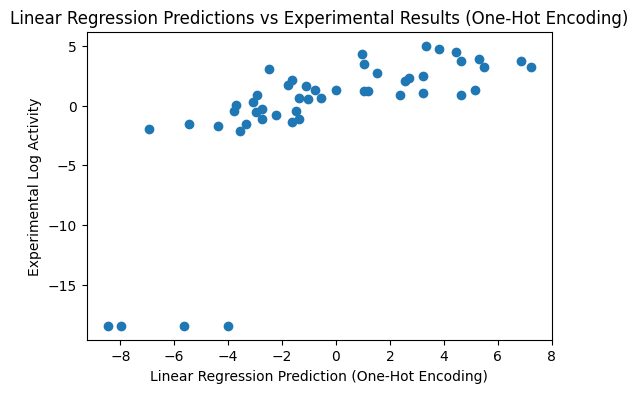

In [101]:
plt.figure(figsize=(6,4))
plt.scatter(x=oh_df.dot(regression_oh.coef_.T) + regression_oh.intercept_, y=y)
plt.xlabel('Linear Regression Prediction (One-Hot Encoding)')
plt.ylabel('Experimental Log Activity')
plt.title('Linear Regression Predictions vs Experimental Results (One-Hot Encoding)')
plt.show()